<a href="https://colab.research.google.com/github/blacktreeM/ar_medicaid/blob/main/ar_med.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
system("apt-get update -qq")
system("apt-get install -y r-cran-fixest r-cran-lfe r-cran-stargazer r-cran-patchwork")
packages <- c("tidyr", "dplyr", "readxl", "ggplot2", "fixest", "lfe", "stargazer", "patchwork")
invisible(lapply(packages, library, character.only = TRUE))
options(repr.plot.width = 10, repr.plot.height = 6)
options(warn = -1); print('ready')

[1] "ready"


Data cleaning

In [3]:
# ==============================================================================
# 1. Load and Clean Urban Institute Medical Debt Data
# ==============================================================================
# https://datacatalog.urban.org/dataset/changing-medical-debt-landscape-united-states
file_name <- 'changing_med_debt_landscape_state.xlsx'
link <- 'https://urban-data-catalog.s3.amazonaws.com/drupal-root-live/2024/07/02/changing_med_debt_landscape_state.xlsx'
if (!file.exists(file_name)) download.file(url = link, destfile = file_name, mode = "wb")
debt <- read_excel(file_name)
colnames(debt) <- c('year', 'fips', 'state', 'share', 'median',
                    'share_white', 'median_white', 'share_nw', 'median_nw',
                    'hospital', 'closure', 'uninsured', 'elderly', 'income')
debt <- debt %>%
  mutate(across(-state, ~ as.numeric(as.character(.)))) %>%
  mutate(state_name = state, state = fips) %>%
  select(-fips)
# ==============================================================================
# 2. Load and Clean UKCPR National Welfare Data
# ==============================================================================
# https://cpr.uky.edu/resources/national-welfare-data
file_name <- 'ukcpr_national_welfare_data_1980_2024_jan26update.xlsx'
link <- 'https://ukcpr.uky.edu/sites/default/files/2026-02/ukcpr_national_welfare_data_1980_2024_jan26update.xlsx'
if (!file.exists(file_name)) download.file(url = link, destfile = file_name, mode = "wb")
state_data <- read_excel(file_name_welfare, sheet = 2)
state_data <- state_data %>%
  select(-state) %>%
  rename('medicaid' = "Medicaid beneficiaries",
         'state_unemp' = "Unemployment rate",
         'state_income' = "Personal income",
         'state_poverty' = "Poverty Rate",
         'pop' = 'Population',
         'gdp' = "Gross State Product",
         'state_governor' = "Governor is Democrat (1=Yes)") %>%
  select(state_name, year, pop, medicaid, contains('state_')) %>%
  filter(year %in% 2011:2023) %>%
  mutate(state_governor = as.numeric(state_governor),
         log_income = log(state_income),
         log_pop = log(pop))
# ==============================================================================
# 3. Load and Clean US Census Bureau Population Data
# ==============================================================================
# https://www.census.gov/data/tables/time-series/demo/popest/2020s-state-detail.html
# https://www.census.gov/data/datasets/time-series/demo/popest/intercensal-2010-2020-state-detail.html
file1 <- 'sc-est2020int-alldata6.csv'
link1 <- 'https://www2.census.gov/programs-surveys/popest/datasets/2010-2020/intercensal/state/asrh/sc-est2020int-alldata6.csv'
file2 <- 'sc-est2024-alldata6.csv'
link2 <- 'https://www2.census.gov/programs-surveys/popest/datasets/2020-2024/state/asrh/sc-est2024-alldata6.csv'
if (!file.exists(file1)) download.file(url = link1, destfile = file1, mode = "wb")
if (!file.exists(file2)) download.file(url = link2, destfile = file2, mode = "wb")
pop1 <- read.csv(file1)
pop2 <- read.csv(file2)
mk <- intersect(colnames(pop1), colnames(pop2))
pop_combined <- pop1 %>% left_join(pop2, by = mk)
pop_combined <- pop_combined %>%
  rename_with(tolower) %>%
  mutate(fips = state) %>%
  select(-sumlev, -region, -division, -name, -estimatesbase2010, -estimatesbase2020, -census2020pop) %>%
  mutate(across(starts_with("popestimate"), ~ as.numeric(.)))
pop_long <- pop_combined %>%
  pivot_longer(cols = starts_with("popestimate"), names_to = "year", values_to = "pop_value") %>%
  mutate(year = gsub('popestimate', '', year),
         year = as.numeric(year))
# Calculate Age Cohorts
total_pop <- pop_long %>% filter(sex == 0 & origin == 0) %>%
  group_by(fips, year) %>% summarise(total_pop = sum(pop_value), .groups = 'drop')
treated <- pop_long %>% filter(age >= 30 & age < 50 & sex == 0 & origin == 0) %>%
  group_by(fips, year) %>% summarise(age3049 = sum(pop_value), .groups = 'drop')
young <- pop_long %>% filter(age <= 18 & sex == 0 & origin == 0) %>%
  group_by(fips, year) %>% summarise(young = sum(pop_value), .groups = 'drop')
old <- pop_long %>% filter(age >= 65 & sex == 0 & origin == 0) %>%
  group_by(fips, year) %>% summarise(old = sum(pop_value), .groups = 'drop')
white <- pop_long %>% filter(sex == 0 & origin == 1 & race == 1) %>%
  group_by(fips, year) %>% summarise(white = sum(pop_value), .groups = 'drop')
black <- pop_long %>% filter(sex == 0 & origin == 1 & race == 2) %>%
  group_by(fips, year) %>% summarise(black = sum(pop_value), .groups = 'drop')
hispanic <- pop_long %>% filter(sex == 0 & origin == 2) %>%
  group_by(fips, year) %>% summarise(hispanic = sum(pop_value), .groups = 'drop')
POP <- total_pop %>%
  left_join(treated,  by = c('fips', 'year')) %>%
  left_join(young,    by = c('fips', 'year')) %>%
  left_join(old,      by = c('fips', 'year')) %>%
  left_join(white,    by = c('fips', 'year')) %>%
  left_join(black,    by = c('fips', 'year')) %>%
  left_join(hispanic, by = c('fips', 'year')) %>%
  rename(state = fips)
POP <- POP %>% mutate(
  white     = white / total_pop,
  black     = black / total_pop,
  hispanic  = hispanic / total_pop,
  pop_share = age3049 / total_pop,
  young     = young / total_pop,
  old       = old / total_pop)
# Merge datasets and clear environment
data <- debt %>%
  left_join(state_data, by = c('state_name', 'year')) %>%
  left_join(POP, by = c('state', 'year'))
save(data, file = 'data.RDa'); print('ready')

[1] "ready"


Descriptive statistics plots

Warning message:
“There were 5 warnings in `mutate()`.
The first warning was:
ℹ In argument: `across(-state, ~as.numeric(as.character(.)))`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 4 remaining warnings.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


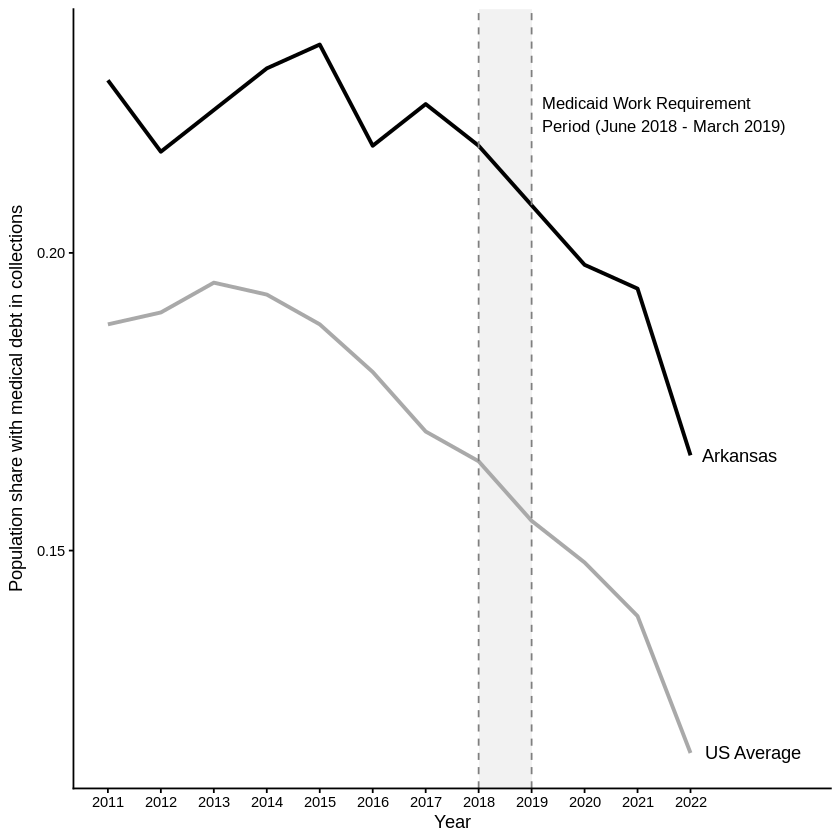

In [11]:
load('data.RDa')
file_name_us <- 'changing_med_debt_landscape_national.xlsx'
link_us <- 'https://urban-data-catalog.s3.amazonaws.com/drupal-root-live/2024/07/02/changing_med_debt_landscape_national.xlsx'
if (!file.exists(file_name_us)) download.file(url = link_us, destfile = file_name_us, mode = "wb")
us <- read_excel(file_name_us)
colnames(us) <- c('year', 'state', 'share', 'median',
                  'share_white', 'median_white', 'share_nw', 'median_nw',
                  'hospital', 'closure', 'uninsured', 'elderly', 'income')
us <- us %>% mutate(across(-state, ~ as.numeric(as.character(.)))) %>% filter(year < 2023)
ar <- data %>%
  filter(state_name == 'AR' & year < 2023) %>%
  mutate(medicaid = medicaid / pop) %>%
  select(year, share, median, medicaid)
usm <- data %>% # Medicaid
  filter(year < 2023) %>%
  group_by(year) %>%
  summarize(medicaid_total = sum(medicaid, na.rm = TRUE), pop_total = sum(pop, na.rm = TRUE)) %>%
  mutate(medicaid = medicaid_total / pop_total) %>%
  ungroup()
# Plot 1: Debt Share
max_share_ar <- max(ar$share, na.rm = TRUE)
ggplot() +
  annotate("rect", xmin = 2018, xmax = 2019, ymin = -Inf, ymax = Inf, fill = "grey90", alpha = 0.5) +
  annotate("text", x = 2019.2, y = max_share_ar * 0.95,
           label = "Medicaid Work Requirement\nPeriod (June 2018 - March 2019)",
           color = "black", size = 3.5, hjust = 0) +
  geom_line(data = ar, aes(x = year, y = share), size = 1.1, color = 'black') +
  geom_line(data = us, aes(x = year, y = share), size = 1.1, color = 'darkgrey') +
  geom_vline(xintercept = c(2018, 2019), linetype = "dashed", color = "grey50") +
  geom_text(data = filter(ar, year == max(year)), aes(x = year, y = share, label = "Arkansas"), hjust = -0.15) +
  geom_text(data = filter(us, year == max(year)), aes(x = year, y = share, label = "US Average"), hjust = -0.15) +
  scale_x_continuous(breaks = 2011:2022, limits = c(2011, 2024)) +
  labs(x = "Year", y = "Population share with medical debt in collections") +
  theme_classic()
ggsave('plot_debt_share.png', height = 4, width = 7)

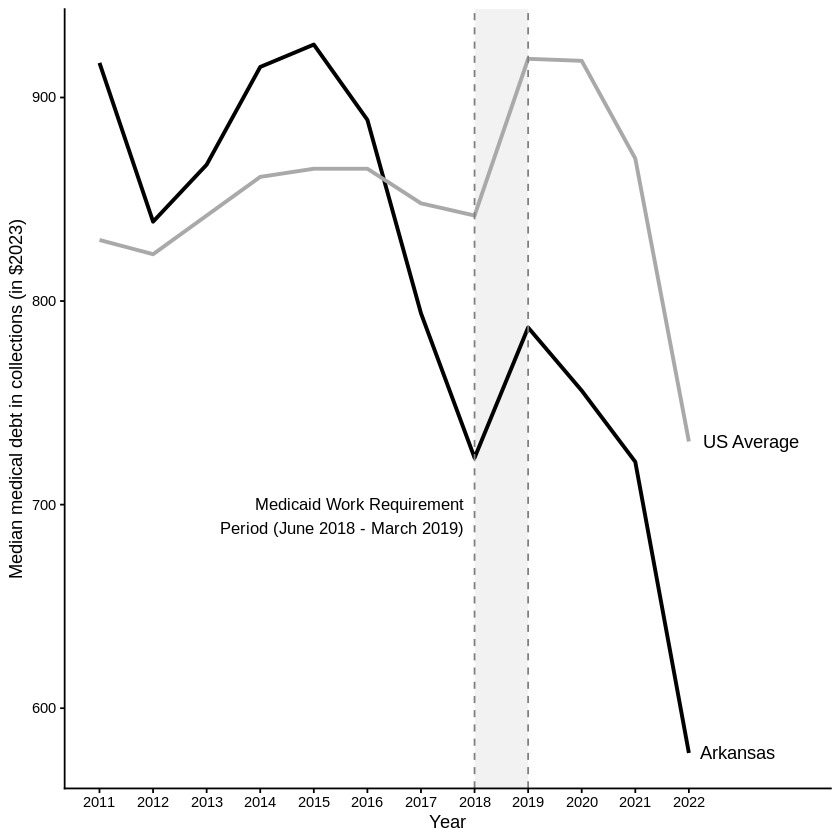

In [12]:
# Plot 2: Median debt
max_median_ar <- max(ar$median, na.rm = TRUE)
ggplot() +
  annotate("rect", xmin = 2018, xmax = 2019, ymin = -Inf, ymax = Inf, fill = "grey90", alpha = 0.5) +
  annotate("text", x = 2017.8, y = max_median_ar * 0.75,
           label = "Medicaid Work Requirement\nPeriod (June 2018 - March 2019)",
           color = "black", size = 3.5, hjust = 1) +
  geom_line(data = ar, aes(x = year, y = median), size = 1.1, color = 'black') +
  geom_line(data = us, aes(x = year, y = median), size = 1.1, color = 'darkgrey') +
  geom_vline(xintercept = c(2018, 2019), linetype = "dashed", color = "grey50") +
  geom_text(data = filter(ar, year == max(year)), aes(x = year, y = median, label = "Arkansas"), hjust = -0.15) +
  geom_text(data = filter(us, year == max(year)), aes(x = year, y = median, label = "US Average"), hjust = -0.15) +
  scale_x_continuous(breaks = 2011:2022, limits = c(2011, 2024)) +
  labs(x = "Year", y = "Median medical debt in collections (in $2023)") +
  theme_classic()

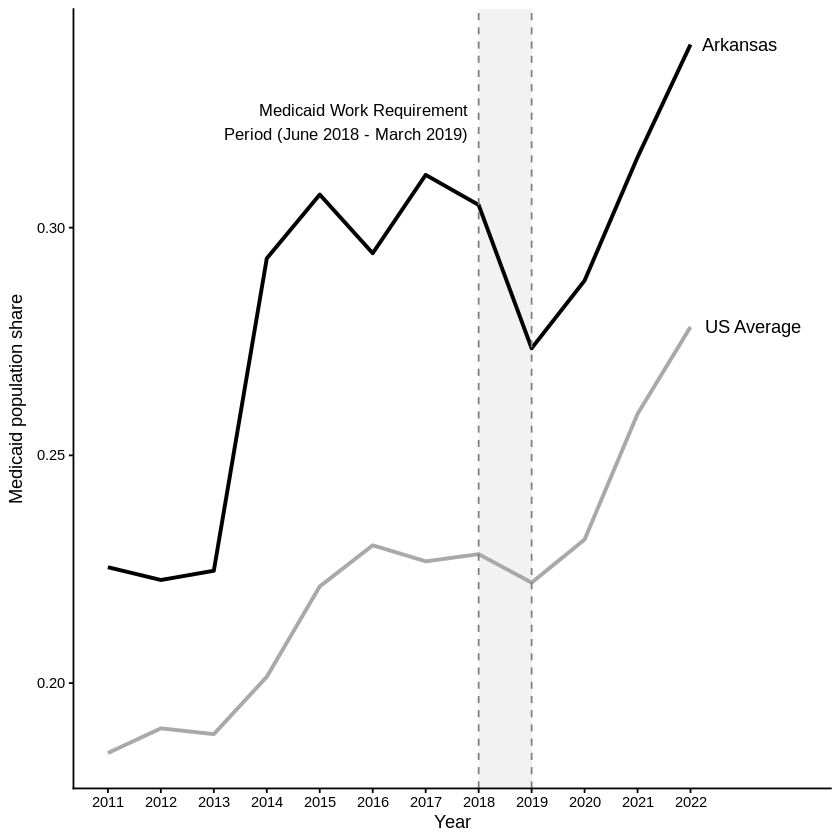

In [13]:
# Plot 3: Medicaid Share
max_medicaid_ar <- max(ar$medicaid, na.rm = TRUE)
ggplot() +
  annotate("rect", xmin = 2018, xmax = 2019, ymin = -Inf, ymax = Inf, fill = "grey90", alpha = 0.5) +
  annotate("text", x = 2017.8, y = max_medicaid_ar * 0.95,
           label = "Medicaid Work Requirement\nPeriod (June 2018 - March 2019)",
           color = "black", size = 3.5, hjust = 1) +
  geom_line(data = ar, aes(x = year, y = medicaid), size = 1.1, color = 'black') +
  geom_line(data = usm, aes(x = year, y = medicaid), size = 1.1, color = 'darkgrey') +
  geom_vline(xintercept = c(2018, 2019), linetype = "dashed", color = "grey50") +
  geom_text(data = filter(ar, year == max(year)), aes(x = year, y = medicaid, label = "Arkansas"), hjust = -0.15) +
  geom_text(data = filter(usm, year == max(year)), aes(x = year, y = medicaid, label = "US Average"), hjust = -0.15) +
  scale_x_continuous(breaks = 2011:2022, limits = c(2011, 2024)) +
  labs(x = "Year", y = "Medicaid population share") +
  theme_classic()
ggsave('plot_medicaid.png', height = 4, width = 7)

Data cleaning

In [14]:
all_states = c(state.abb, "DC")
late <- c(
  "PA", "IN", "AK",        # Expanded in 2015
  "MT", "LA",              # Expanded in 2016
  "ME", "VA",              # Expanded in 2019
  "ID", "NE", "UT",        # Expanded in 2020
  "MO", "OK",              # Expanded in 2021
  "SD", "NC"               # Expanded in 2023
)
never <- c("AL", "FL", "GA", "KS", "MS", "SC", "TN", "TX", "WY", 'WI')
donor_pool_states = setdiff(all_states, late); length(donor_pool_states)
donor_pool_states = setdiff(donor_pool_states, never); length(donor_pool_states)
data = data %>% mutate(treat = ifelse(state_name=='AR' & year>=2017, 1, 0),
                       ar = ifelse(state_name=='AR', 1, 0),
                       time_to_treat = year - 2017,
                       log_median = log(median)) %>%
  filter(year < 2023); table(data$treat, data$year) ## drop 2023 because credit bureau changed policy
data14 = data %>% filter(state_name %in% donor_pool_states)


[1] 37

[1] 27

   
    2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022
  0   51   51   51   51   51   51   50   50   50   50   50   50
  1    0    0    0    0    0    0    1    1    1    1    1    1

Difference-in-differences

In [16]:
result_share = list(felm(share ~ treat | state + year | 0 | state, data = data, weights = data$age3049),
                    felm(share ~ treat + state_unemp + log_income + state_poverty + pop_share + young + old |
                           state + year | 0 | state, data = data, weights = data$age3049),
                    felm(share ~ treat | state + year | 0 | state, data = data14, weights = data14$age3049),
                    felm(share ~ treat + state_unemp + log_income + state_poverty + pop_share + young + old |
                           state + year | 0 | state, data = data14, weights = data14$age3049))
stargazer(result_share, dep.var.labels.include = F, out = 'reg_share.html',
          type = 'text', no.space=T, omit.stat = c("rsq","ser"), model.numbers = T,
          title='Table 2. Regression results', #star.cutoffs = c(0.05, 0.01, 0.00),
          dep.var.labels = "Share of population with medical debt",
          covariate.labels = c('Treat', 'ln(Income)', 'Poverty rate', 'Unemployment rate',
                               'Percent age 30-49', 'Percent age 65 or older',
                               'Percent age 18 or younger'),
          add.lines = list(c("State and year fixed effects", rep('Yes', 4)),
                           c("Number of states",   "51",  "51", "27", '27')))


Table 2. Regression results
                                     Dependent variable:        
                             -----------------------------------
                               (1)      (2)      (3)      (4)   
----------------------------------------------------------------
Treat                        0.017*** 0.015*** 0.015***  0.010* 
                             (0.003)  (0.003)  (0.003)  (0.005) 
ln(Income)                             0.001             0.002  
                                      (0.001)           (0.002) 
Poverty rate                          -0.101**           -0.128 
                                      (0.048)           (0.081) 
Unemployment rate                     -0.0002            0.0004 
                                      (0.0005)          (0.0005)
Percent age 30-49                      -0.364            -0.145 
                                      (0.452)           (0.732) 
Percent age 65 or older                -0.447            -0.6

In [18]:
result_median = list(felm(log_median ~ treat | state + year | 0 | state, data = data, weights = data$age3049),
                    felm(log_median ~ treat + state_unemp + log_income + state_poverty + pop_share + young + old |
                           state + year | 0 | state, data = data, weights = data$age3049),
                    felm(log_median ~ treat | state + year | 0 | state, data = data14, weights = data14$age3049),
                    felm(log_median ~ treat + state_unemp + log_income + state_poverty + pop_share + young + old |
                           state + year | 0 | state, data = data14, weights = data14$age3049))
stargazer(result_median, dep.var.labels.include = F, out = 'reg_median.html',
          type = 'text', no.space=T, omit.stat = c("rsq","ser"), model.numbers = T,
          title='Table 2. Regression results', #star.cutoffs = c(0.05, 0.01, 0.00),
          dep.var.labels = "Share of population with medical debt",
          covariate.labels = c('Treat', 'ln(Income per capita)', 'Poverty rate', 'Unemployment rate',
                               'Percent age 30-49', 'Percent age 65 or older',
                               'Percent age 18 or younger'),
          add.lines = list(c("State and year fixed effects", rep('Yes', 4)),
                           c("Number of states",   "51",  "51", "27", '27')))


Table 2. Regression results
                                       Dependent variable:          
                             ---------------------------------------
                                (1)       (2)       (3)       (4)   
--------------------------------------------------------------------
Treat                        -0.190*** -0.260*** -0.119*** -0.140***
                              (0.023)   (0.034)   (0.022)   (0.040) 
ln(Income per capita)                   -0.012              -0.003  
                                        (0.010)             (0.015) 
Poverty rate                             0.001              -0.524  
                                        (0.380)             (0.515) 
Unemployment rate                       -0.002              -0.006  
                                        (0.004)             (0.006) 
Percent age 30-49                       -4.972              -2.856  
                                        (3.511)             (4.959) 
Perce

Event study

,beta,se,year
,<dbl>,<dbl>,<int>
time_to_treat::-6:ar,0.0005672822,0.003597996,2011
time_to_treat::-5:ar,-0.0101394468,0.003569893,2012
time_to_treat::-4:ar,-0.0095329018,0.002849313,2013
time_to_treat::-3:ar,-0.0005318964,0.002413550,2014
time_to_treat::-2:ar,0.0076916621,0.001582220,2015
,0.0000000000,0.000000000,2016
time_to_treat::0:ar,0.0154235637,0.001480576,2017
time_to_treat::1:ar,0.0120661422,0.002228590,2018
time_to_treat::2:ar,0.0113657055,0.002711814,2019


,beta,se,year
,<dbl>,<dbl>,<int>
time_to_treat::-6:ar,0.002050123,0.006201899,2011
time_to_treat::-5:ar,-0.010244438,0.004898931,2012
time_to_treat::-4:ar,-0.007129413,0.004049006,2013
time_to_treat::-3:ar,0.001028197,0.002670638,2014
time_to_treat::-2:ar,0.008843584,0.001395036,2015
,0.000000000,0.000000000,2016
time_to_treat::0:ar,0.013882728,0.001939284,2017
time_to_treat::1:ar,0.009728250,0.002852133,2018
time_to_treat::2:ar,0.009692030,0.003791442,2019


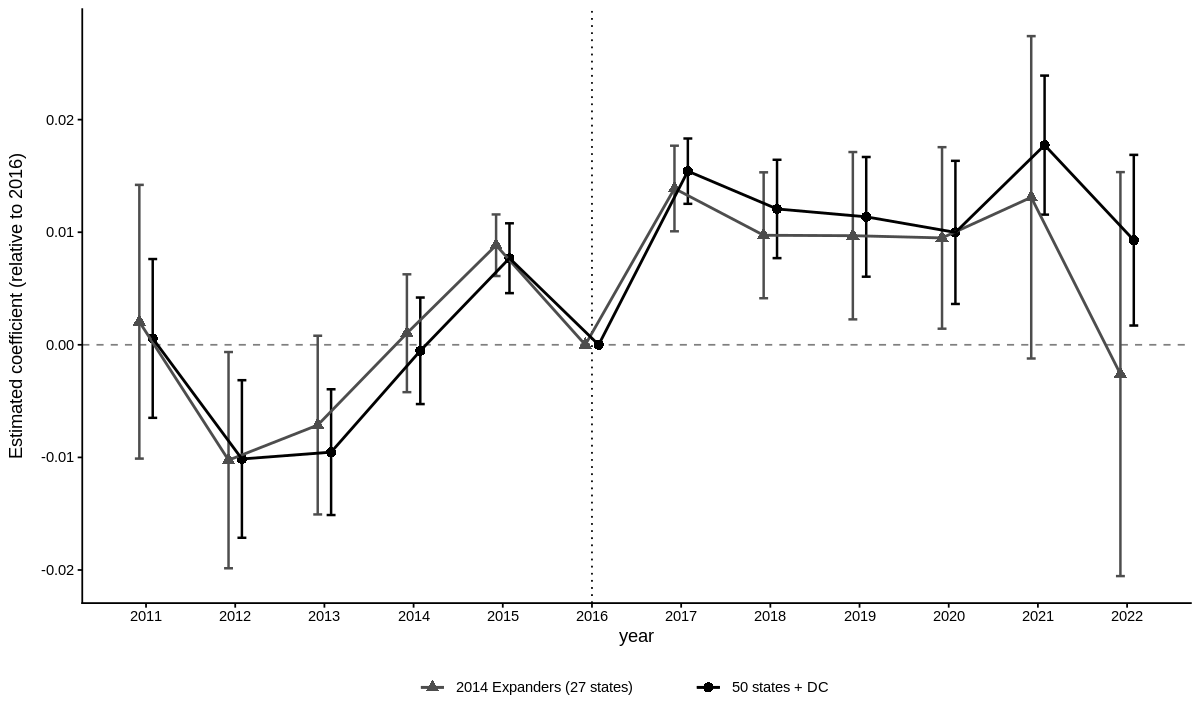

In [20]:
share_all <- feols(share ~ i(time_to_treat, ar, ref = -1) +
                    state_unemp + log_income + state_poverty + pop_share + young + old| year + state,
                  cluster = ~state, data = data, weights = ~age3049)
share_14 <- feols(share ~ i(time_to_treat, ar, ref = -1) +
                     state_unemp + log_income + state_poverty + pop_share + young + old| year + state,
                   cluster = ~state, data = data14, weights = ~age3049)
(event_share = data.frame(beta = c(share_all$coefficients[1:5], 0, share_all$coefficients[6:11]),
                          se = c(share_all$se[1:5], 0, share_all$se[6:11]), year = 2011:2022))
(event_share14 = data.frame(beta = c(share_14$coefficients[1:5], 0, share_14$coefficients[6:11]),
                          se = c(share_14$se[1:5], 0, share_14$se[6:11]), year = 2011:2022))
share_event_data <- bind_rows(
  event_share %>% mutate(Specification = "50 states + DC"),
  event_share14 %>% mutate(Specification = "2014 Expanders (27 states)"))
ggplot(share_event_data, aes(x = year, y = beta, color = Specification, shape = Specification)) +
  theme_classic() +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.5) +
  geom_vline(xintercept = 2016, linetype = "dotted", color = "black", linewidth = 0.5) +
  geom_errorbar(aes(ymin = beta - 1.96 * se, ymax = beta + 1.96 * se),
                width = 0.2, linewidth = 0.7, position = position_dodge(width = 0.3)) +
  geom_point(size = 2.5, position = position_dodge(width = 0.3)) +
  geom_line(aes(group = Specification), linewidth = 0.8, position = position_dodge(width = 0.3)) +
  labs(y = "Estimated coefficient (relative to 2016)", color = NULL, shape = NULL) +
  scale_x_continuous(breaks = 2011:2022) +
  scale_color_manual(values = c("50 states + DC" = "black",
                                "2014 Expanders (27 states)" = "grey30")) +
  scale_shape_manual(values = c("50 states + DC" = 16,
                                "2014 Expanders (27 states)" = 17)) +
  theme(legend.position = "bottom", legend.title = element_blank(),
    axis.text = element_text(color = "black")); ggsave('plot_event_share.png', height = 4, width = 7)

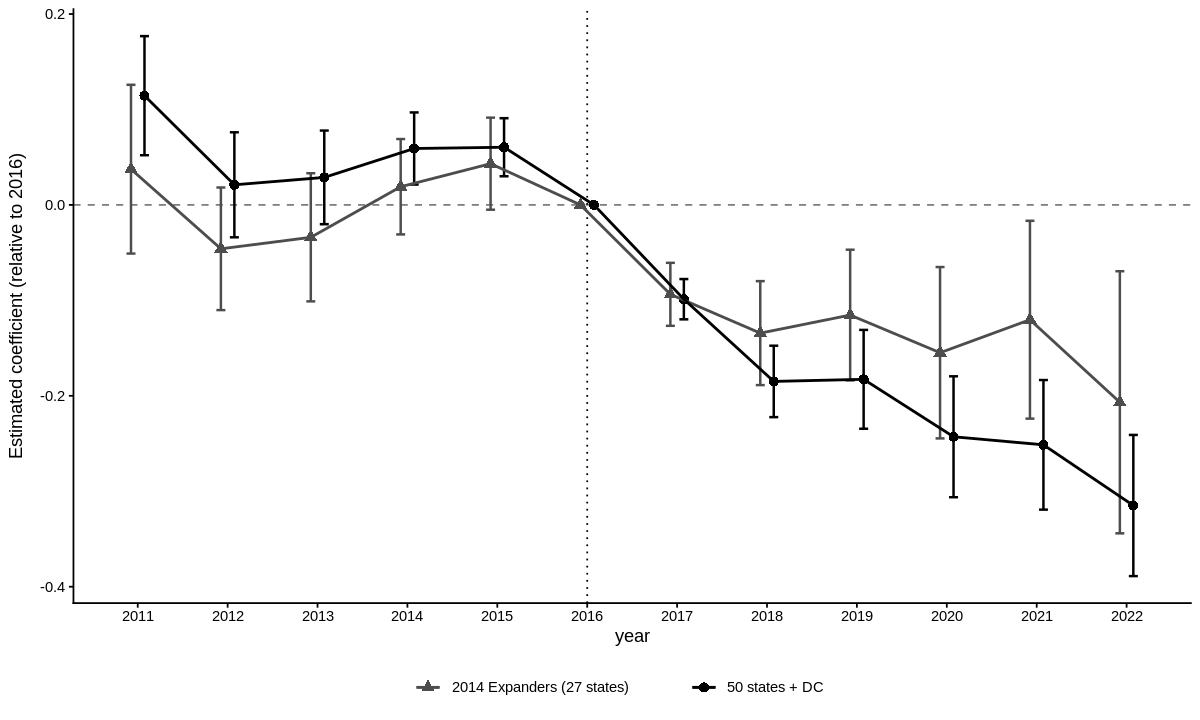

In [24]:
median_all <- feols(log_median ~ i(time_to_treat, ar, ref = -1) +
                     state_unemp + log_income + state_poverty + pop_share + young + old | year + state,
                   cluster = ~state, data = data, weights = ~age3049)
median_14 <- feols(log_median ~ i(time_to_treat, ar, ref = -1) +
                    state_unemp + log_income + state_poverty + pop_share + young + old | year + state,
                  cluster = ~state, data = data14, weights = ~age3049)
event_median <- data.frame(beta = c(median_all$coefficients[1:5], 0, median_all$coefficients[6:11]),
  se   = c(median_all$se[1:5], 0, median_all$se[6:11]), year = 2011:2022)
event_median14 <- data.frame(beta = c(median_14$coefficients[1:5], 0, median_14$coefficients[6:11]),
  se   = c(median_14$se[1:5], 0, median_14$se[6:11]), year = 2011:2022)
median_event_data <- bind_rows(event_median %>% mutate(Specification = "50 states + DC"),
  event_median14 %>% mutate(Specification = "2014 Expanders (27 states)"))
ggplot(median_event_data, aes(x = year, y = beta, color = Specification, shape = Specification)) +
  theme_classic() +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.5) +
  geom_vline(xintercept = 2016, linetype = "dotted", color = "black", linewidth = 0.5) +
  geom_errorbar(aes(ymin = beta - 1.96 * se, ymax = beta + 1.96 * se),
                width = 0.2, linewidth = 0.7, position = position_dodge(width = 0.3)) +
  geom_point(size = 2.5, position = position_dodge(width = 0.3)) +
  geom_line(aes(group = Specification), linewidth = 0.8, position = position_dodge(width = 0.3)) +
  labs(y = "Estimated coefficient (relative to 2016)", color = NULL, shape = NULL) +
  scale_x_continuous(breaks = 2011:2022) +
  scale_color_manual(values = c("50 states + DC" = "black",
                                "2014 Expanders (27 states)" = "grey30")) +
  scale_shape_manual(values = c("50 states + DC" = 16,
                                "2014 Expanders (27 states)" = 17)) +
  theme(legend.position = "bottom",
    legend.title = element_blank(),
    axis.text = element_text(color = "black")); ggsave('plot_event_median.png', height = 4, width = 7)

Synthetic controls

Ignoring unknown labels:
• colour : ""
• linetype : ""


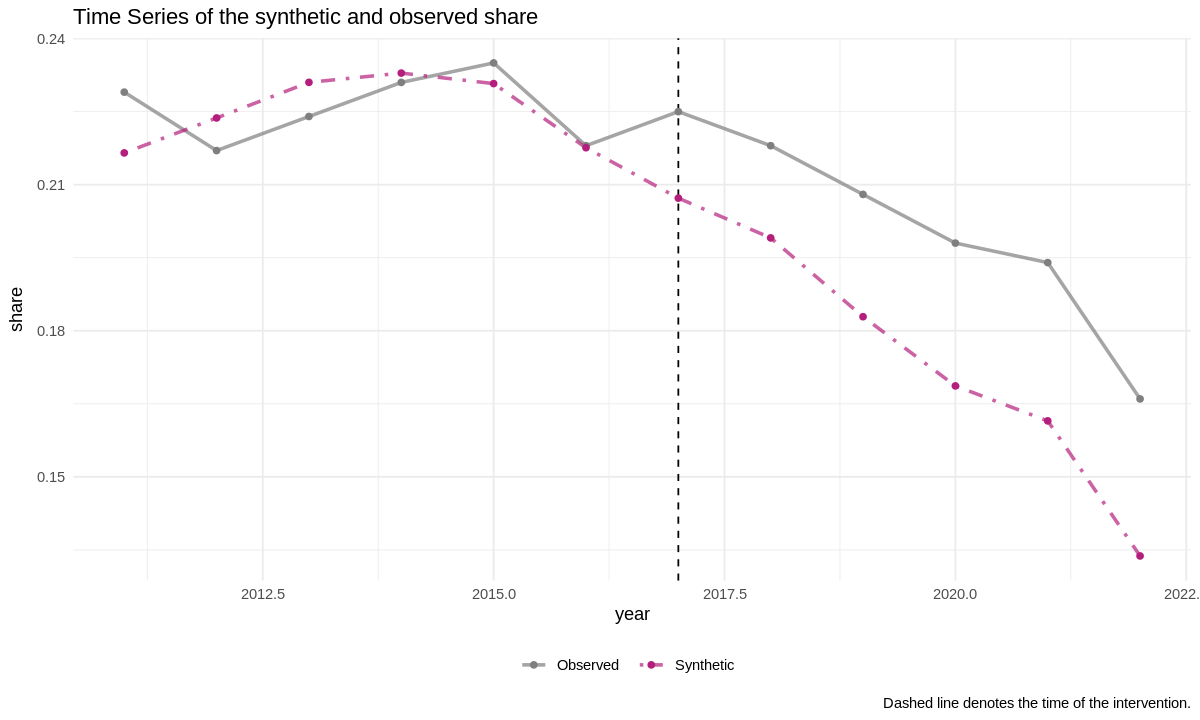

Ignoring unknown labels:
• colour : ""


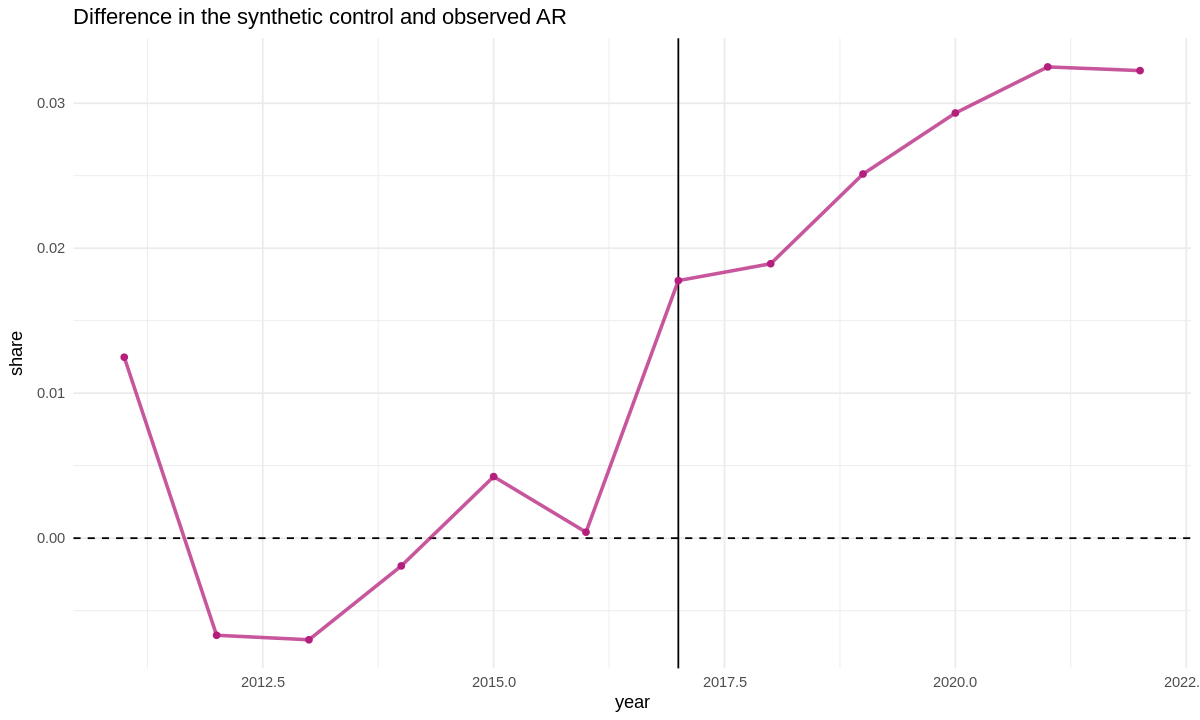

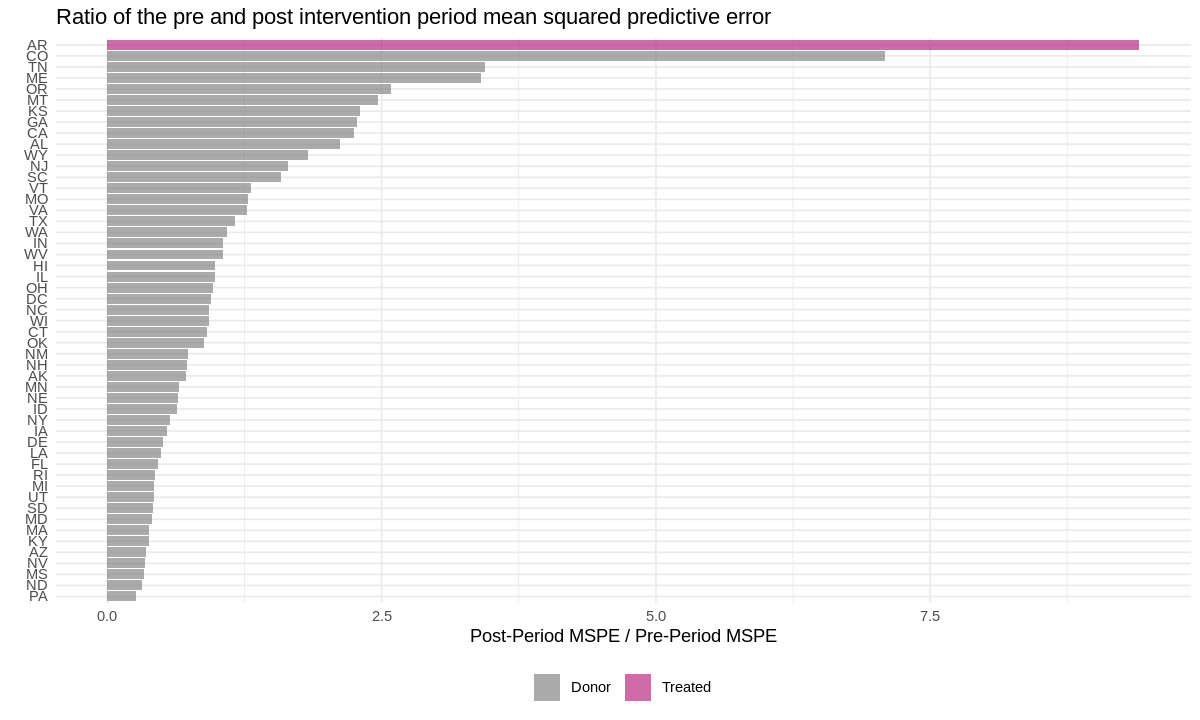

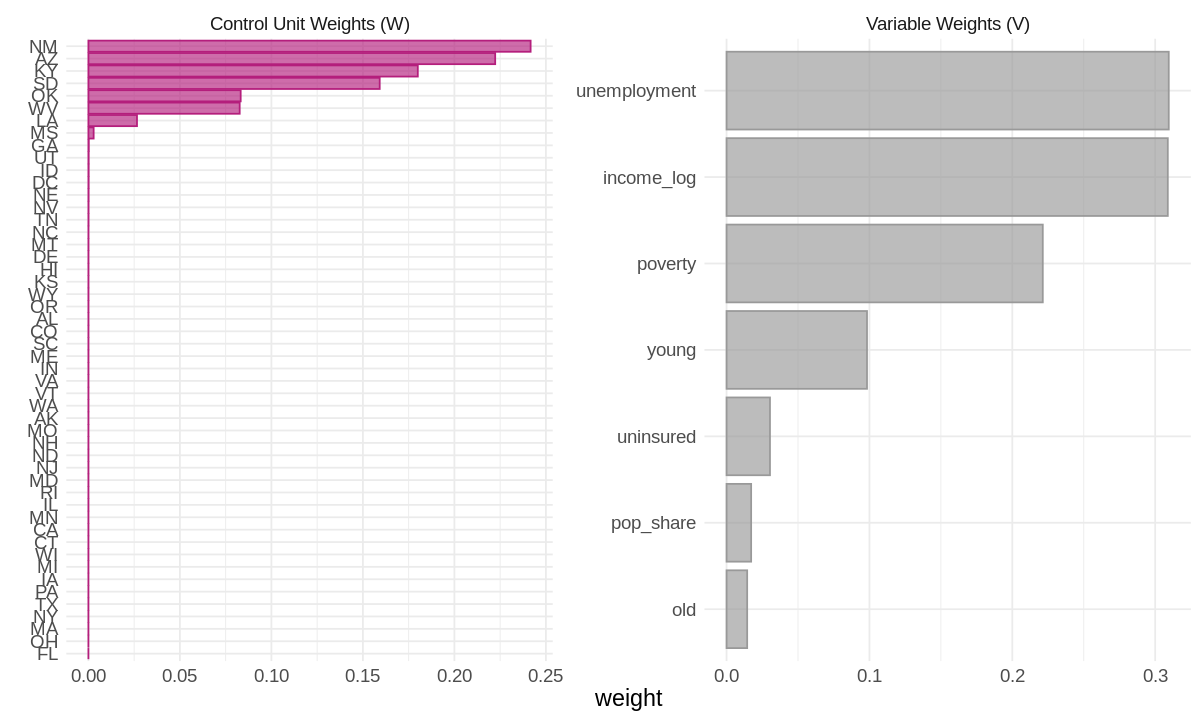

In [26]:
system("apt-get update -qq")
system("apt-get install -y r-cran-tidysynth")
library("tidysynth")
sc = function(df, outcome_var) {
  outcome_sym <- as.name(outcome_var)
  sc_output <- df %>%
    synthetic_control(
      outcome           = !!outcome_sym,
      unit              = state_name,
      time              = year,
      i_unit            = "AR",
      i_time            = 2017,
      generate_placebos = T) %>%
    generate_predictor(
      time_window  = 2011:2016,
      unemployment = mean(state_unemp),
      income_log   = mean(log_income),
      poverty      = mean(state_poverty),
      pop_share    = mean(pop_share),
      young        = mean(young),
      old          = mean(old),
      #black        = mean(black),
      #hispanic     = mean(hispanic),
      uninsured    = mean(uninsured)) %>%
    #generate_predictor(time_window = 2011:2013,
                       #lagged_2011 = mean(!!outcome_sym),
     #                  uninsured1    = mean(uninsured)) %>%
    #generate_predictor(time_window = 2014:2015,
                       #lagged_2014 = mean(!!outcome_sym),
     #                  uninsured2    = mean(uninsured)) %>%
    #generate_predictor(time_window = 2016, lagged_2016 = !!outcome_sym) %>%
    generate_weights(optimization_window = 2011:2016,
      sigf_ipop = 7, margin_ipop = 0.02, bound_ipop = 6) %>% generate_control()
  return(sc_output)
}

In [ ]:

share = sc(data, 'share')
share14 = sc(data14, 'share')
share %>% plot_trends()
share %>% plot_differences()
share %>% plot_mspe_ratio()
share %>% plot_weights()
#
